   symboling normalized-losses         make fuel-type aspiration num-of-doors  \
0          3                 ?  alfa-romero       gas        std          two   
1          3                 ?  alfa-romero       gas        std          two   
2          1                 ?  alfa-romero       gas        std          two   
3          2               164         audi       gas        std         four   
4          2               164         audi       gas        std         four   

    body-style drive-wheels engine-location  wheel-base  ...  engine-size  \
0  convertible          rwd           front        88.6  ...          130   
1  convertible          rwd           front        88.6  ...          130   
2    hatchback          rwd           front        94.5  ...          152   
3        sedan          fwd           front        99.8  ...          109   
4        sedan          4wd           front        99.4  ...          136   

   fuel-system  bore  stroke compression-ratio hor

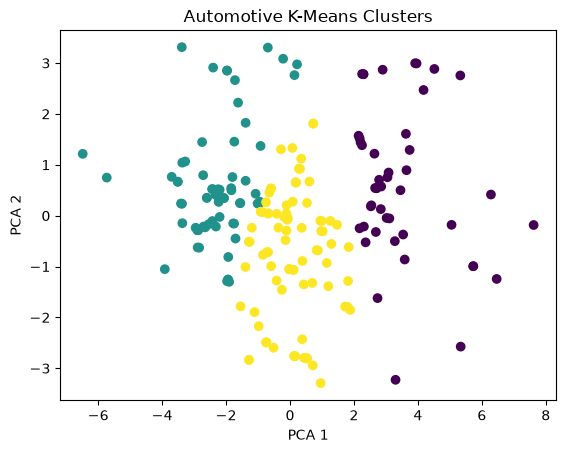

KeyError: 'description'

In [1]:
# 1. Import libraries
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import PCA

# 2. Load dataset
df = pd.read_csv("automotive_data.csv")
print(df.head())

# 3. K-Means on numerical data
num = df.select_dtypes(include="number").columns
X = df[num].fillna(df[num].median())

X = StandardScaler().fit_transform(X)

# 4. K-Means clustering
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
df["Cluster"] = kmeans.fit_predict(X)

print(df.groupby("Cluster")[num].mean())

# 5. Visualise clusters
pca = PCA(n_components=2)
P = pca.fit_transform(X)

plt.scatter(P[:,0], P[:,1], c=df["Cluster"])
plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.title("Automotive K-Means Clusters")
plt.show()

# 6. NLP
# Change 'description' to your text column if necessary
text = df["description"].fillna("").astype(str)

tfidf = TfidfVectorizer(stop_words="english")
T = tfidf.fit_transform(text)

# 7. NLP K-Means
nlp = KMeans(n_clusters=3, random_state=42, n_init=10)
df["NLP_Cluster"] = nlp.fit_predict(T)

# 8. Show results
print(df[["description", "NLP_Cluster"]].head(10))

# 9. Save results
df.to_csv("automotive_clustered.csv", index=False)
print("Done!")